DataFrame: Export
       Unnamed: 0  \
0  Empreendimento   
1           10028   
2           10032   
3           10033   
4           10034   

  Data de referência dos dados: 01 de setembro de 2025 (As coordenadas ausentes encontram-se em verificação).  \
0                                                CEG                                                            
1                                 UFV.RS.MS.070379-6                                                            
2                                 UFV.RS.MS.070380-0                                                            
3                                 UFV.RS.MS.070381-8                                                            
4                                 UFV.RS.MS.070382-6                                                            

  Unnamed: 2 Unnamed: 3 Unnamed: 4 Unnamed: 5      Unnamed: 6  \
0         UF      Fonte       Fase     Origem            Tipo   
1         MS        UFV   Operação      Solar 

/tmp/ipython-input-2663001822.py:42: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], dayfirst=True, errors='coerce')
/tmp/ipython-input-2663001822.py:42: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], dayfirst=True, errors='coerce')


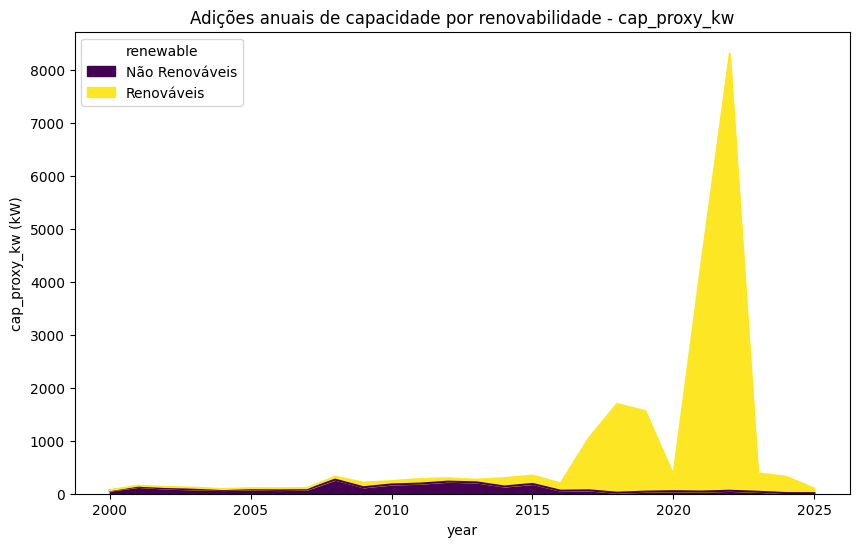

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === 1. Ler todas as abas ===
FILEPATH = '/content/BD_SIGA.xlsx'
dataframes = pd.read_excel(FILEPATH, sheet_name=None)

for k, v in dataframes.items():
    print(f"DataFrame: {k}")
    print(v.head(5))

# === 2. Selecionar aba Export ===
df = dataframes.get('Export').copy()
print("Loaded Export sheet into df")

# === 3. Limpeza dos nomes de colunas ===
df.columns = df.columns.astype(str).str.strip()

# Se primeira linha for cabeçalho
if df.columns[0] != 'Empreendimento':
    new_header = df.iloc[0].astype(str).tolist()
    df = df[1:].copy()
    df.columns = [c.strip() for c in new_header]

print(df.head(10))

# === 4. Normalizar nomes de colunas (sem acentos/bugs) ===
df.columns = (
    df.columns.str.normalize("NFKD")
    .str.encode("ascii", errors="ignore")
    .str.decode("utf-8")
    .str.lower()
    .str.replace(" ", "_")
)

print("Colunas normalizadas:", df.columns.tolist())

# === 5. Ajuste de datas ===
for col in ['entrada_em_operacao', 'inicio_vigencia', 'fim_vigencia']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], dayfirst=True, errors='coerce')

# === 6. Ajuste numérico ===
for col in ['pot_outorgada_kw', 'pot_fiscalizada_kw', 'garantia_fisica_kw', 'latitude_decimal', 'longitude_decimal']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# === 7. Identificação de fontes renováveis ===
renew_map = {
    'UFV': True, 'UHE': True, 'PCH': True, 'CGH': True, 'EOL': True,
    'UTE': False, 'UTEG': False, 'UTE GN': False, 'UTN': False, 'UTE CARVAO': False, 'UTE OLEO': False
}

def is_renewable(row):
    fonte = str(row.get('fonte', '')).upper()
    comb = str(row.get('combustivel_final', '')).upper()
    if fonte in renew_map:
        return renew_map[fonte]
    if any(x in comb for x in ['SOLAR','RADIACAO','VENTO','WIND','HIDR','AGUA','BIOMASS','LENHA','LIXO']):
        return True
    if any(x in comb for x in ['GN','GAS NAT','CARVAO','CARBON','OLEO','DIESEL','FUEL','NAFTA']):
        return False
    return np.nan

df['renewable'] = df.apply(is_renewable, axis=1)

# === 8. Preparar séries temporais ===
df_ts = df.dropna(subset=['entrada_em_operacao']).copy()
df_ts = df_ts[df_ts['entrada_em_operacao'].dt.year >= 2000].copy()
df_ts['year'] = df_ts['entrada_em_operacao'].dt.year

agg_cols = [c for c in ['pot_outorgada_kw','pot_fiscalizada_kw','garantia_fisica_kw'] if c in df_ts.columns]
if not agg_cols:
    df_ts['cap_proxy_kw'] = 1.0
    agg_cols = ['cap_proxy_kw']

# === 9. Agregar por ano e fonte ===
group_year = df_ts.groupby(['year','renewable'])[agg_cols].sum().reset_index()
group_fonte_year = df_ts.groupby(['year','fonte'])[agg_cols].sum().reset_index()

# === 10. Shares ===
year_totals = df_ts.groupby('year')[agg_cols].sum().reset_index()
group_year = group_year.merge(year_totals, on='year', suffixes=('','_total'))
for col in agg_cols:
    group_year[col+'_share'] = group_year[col] / group_year[col+'_total']

# === 11. Plot exemplo ===
metric = agg_cols[0]
pivot = group_year.pivot(index='year', columns='renewable', values=metric).fillna(0)
pivot.rename(columns={True:'Renováveis', False:'Não Renováveis'}, inplace=True)
pivot.plot(kind='area', stacked=True, figsize=(10,6), colormap='viridis')
plt.title(f'Adições anuais de capacidade por renovabilidade - {metric}')
plt.ylabel(f'{metric} (kW)')
plt.show()


In [2]:
col = 'potencia_outorgada_(kw)'
df[col] = (df[col].astype(str)
            .str.replace(r'\.', '', regex=True)   # remove pontos de milhares
            .str.replace(r',', '.', regex=True)   # transforma vírgula decimal em ponto
            .str.replace(r'[^\d\.\-]', '', regex=True)  # mantém só números, ponto, menos
           )
df[col] = pd.to_numeric(df[col], errors='coerce')


In [3]:
# normalizar
df['fonte_norm'] = (df['fonte'].astype(str)
                      .str.upper().str.normalize('NFKD')
                      .str.encode('ascii', errors='ignore').str.decode('utf-8')
                      .str.replace(r'\s+',' ', regex=True).str.strip())

# mapear
mapping = {
 'UFV':'UFV','SOLAR':'UFV','FOTOVOLTAICA':'UFV',
 'UHE':'UHE','HIDRO':'UHE',
 'PCH':'PCH','CGH':'CGH',
 'EOL':'EOL','EOLICO':'EOL',
 'UTN':'UTN','NUCLEAR':'UTN',
 'UTE':'UTE', 'TERMEL':'UTE' # mas refine com combustivel if contains BIO/BIOENERGIA -> renewable
}

# apply fuzzy rules or startswith checks, then derive renewable flag
def fonte_to_code(s):
    for k,v in mapping.items():
        if k in s:
            return v
    return s  # fallback

df['fonte_code'] = df['fonte_norm'].apply(fonte_to_code)

# derive renewable
renew_map = {'UFV':True,'UHE':True,'PCH':True,'CGH':True,'EOL':True,'UTN':False,'UTE':False}
df['renewable'] = df['fonte_code'].map(renew_map)
# refine by combustivel_final: if contains BIOMASS/BIO -> True
df.loc[df['combustivel_final'].astype(str).str.upper().str.contains('BIO|BIOMASSA|BIOMASS'), 'renewable'] = True


In [4]:
# ======== Rodando novamente o código para garantir a correta mudança dos nomes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# 1. Carregar base e tratar colunas
# ============================================
try:
    df = pd.read_csv("BD_SIGA - Export.csv")
except FileNotFoundError:
    print("Erro: O arquivo 'BD_SIGA - Export (1).csv' não foi encontrado.")
    print("Por favor, verifique o nome ou o caminho do arquivo.")
    exit()

# Padronizar nomes de colunas ANTES de qualquer outra operação
df.columns = (df.columns
                .str.strip()
                .str.lower()
                .str.replace(" ", "_")
                .str.replace("[^0-9a-zA-Z_]", "", regex=True))

# ============================================
# 2. Tratar datas e filtrar a partir de 2000
# ============================================
# Ajusta para o nome da coluna padronizado ('entrada_em_operao')
if "entrada_em_operao" in df.columns:
    df["entrada_em_operacao"] = pd.to_datetime(df["entrada_em_operao"], dayfirst=True, errors="coerce")
elif "data_entrada_operacao" in df.columns:
    df["entrada_em_operacao"] = pd.to_datetime(df["data_entrada_operacao"], dayfirst=True, errors="coerce")
else:
    raise KeyError("Coluna de entrada em operação não encontrada após padronização.")

df = df.dropna(subset=["entrada_em_operacao"])
df["year"] = df["entrada_em_operacao"].dt.year

# 🔹 Filtro temporal
df = df[df["year"] >= 2000].copy()

# ============================================
# 3. Potência outorgada (limpeza)
# ============================================
if "potncia_outorgada_kw" in df.columns:
    col_potencia = "potncia_outorgada_kw"
    df[col_potencia] = (df[col_potencia].astype(str)
                        .str.replace(r"\.", "", regex=True)
                        .str.replace(",", ".", regex=True)
                        .str.replace(r"[^\d\.]", "", regex=True))
    df[col_potencia] = pd.to_numeric(df[col_potencia], errors="coerce")
else:
    raise KeyError("Coluna 'potncia_outorgada_kw' não encontrada.")

In [5]:
# Normalizar fontes
df["fonte_norm"] = df["fonte"].astype(str).str.upper()

renew_map = {
    "UFV": True, "UHE": True, "PCH": True, "CGH": True, "EOL": True,
    "UTN": False, "UTE": False
}

df["renewable"] = df["fonte_norm"].map(renew_map)


In [6]:
# Agregado por ano e renovabilidade
year_group = df.groupby(["year", "renewable"])["potncia_outorgada_kw"].sum().reset_index()

# Agregado por fonte
fonte_group = df.groupby(["year", "fonte"])["potncia_outorgada_kw"].sum().reset_index()

In [7]:
periods = [
    ("Lula 1", 2003, 2006),
    ("Lula 2", 2007, 2010),
    ("Dilma-Temer", 2011, 2018),
    ("Bolsonaro", 2019, 2022),
    ("Lula 3", 2023, 2026)
]

def period_label(y):
    for name, y0, y1 in periods:
        if y >= y0 and y <= y1:
            return name
    return "Outros"

df["period"] = df["year"].apply(period_label)

period_group = df.groupby(["period", "renewable"])["potncia_outorgada_kw"].sum().reset_index()


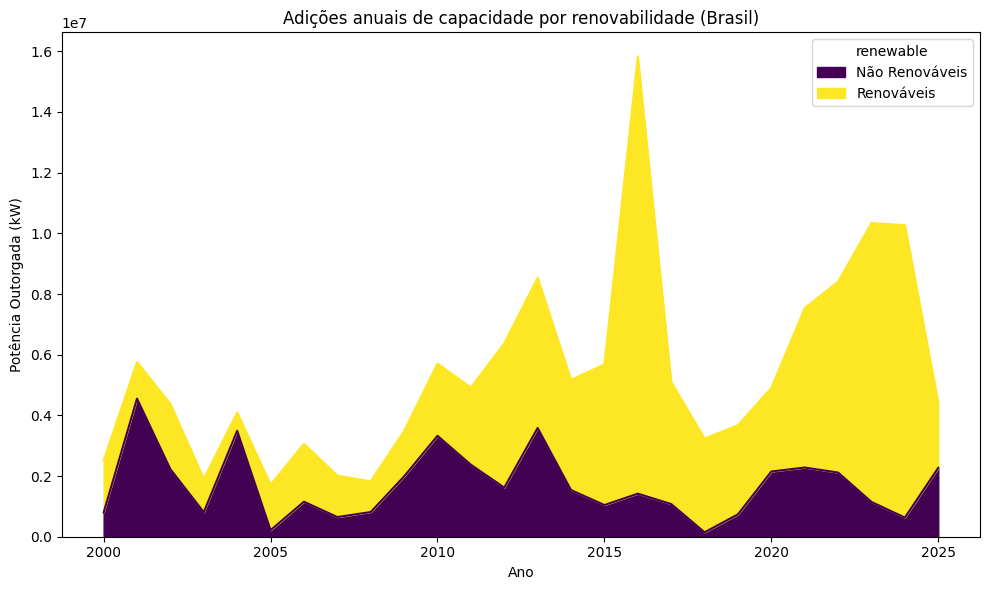

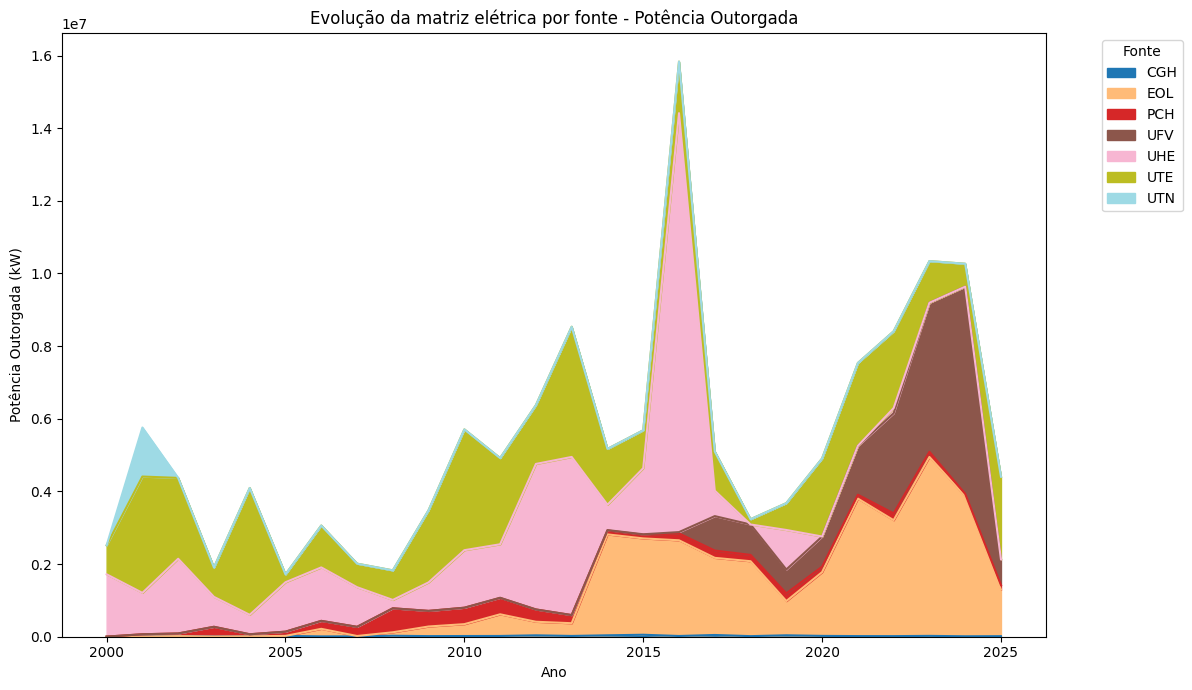

In [8]:
# Renováveis vs não-renováveis (área empilhada)
pivot_year = year_group.pivot(index="year", columns="renewable", values="potncia_outorgada_kw").fillna(0)
pivot_year.rename(columns={True: "Renováveis", False: "Não Renováveis"}, inplace=True)

pivot_year.plot(kind="area", stacked=True, figsize=(10,6), colormap="viridis")
plt.title("Adições anuais de capacidade por renovabilidade (Brasil)")
plt.xlabel("Ano")
plt.ylabel("Potência Outorgada (kW)")
plt.tight_layout()
plt.show()

# Evolução por fonte
pivot_fonte = fonte_group.pivot(index="year", columns="fonte", values="potncia_outorgada_kw").fillna(0)
pivot_fonte.plot(kind="area", stacked=True, figsize=(12,7), colormap="tab20")
plt.title("Evolução da matriz elétrica por fonte - Potência Outorgada")
plt.xlabel("Ano")
plt.ylabel("Potência Outorgada (kW)")
plt.legend(title="Fonte", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

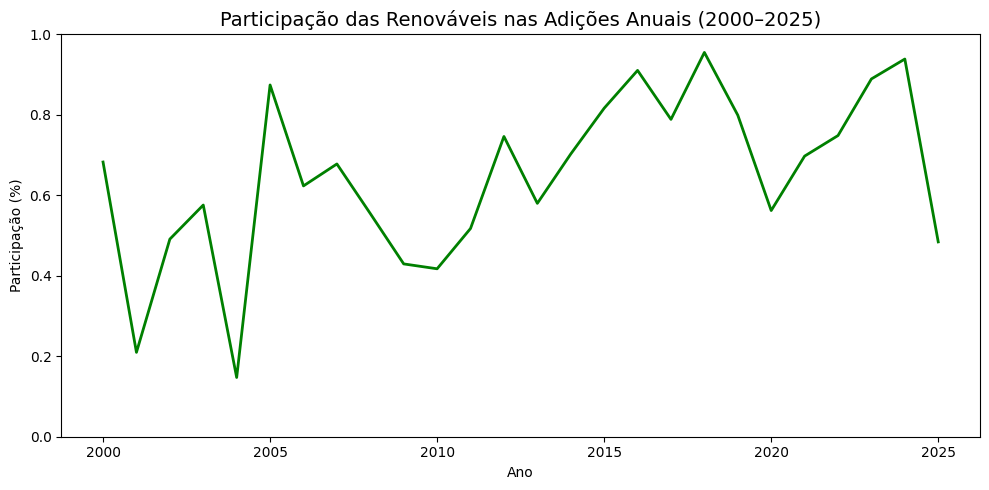

In [9]:
share = pivot_year["Renováveis"] / pivot_year.sum(axis=1)

plt.figure(figsize=(10,5))
share.plot(color="green", linewidth=2)
plt.title("Participação das Renováveis nas Adições Anuais (2000–2025)", fontsize=14)
plt.xlabel("Ano")
plt.ylabel("Participação (%)")
plt.ylim(0,1)
plt.tight_layout()
plt.show()


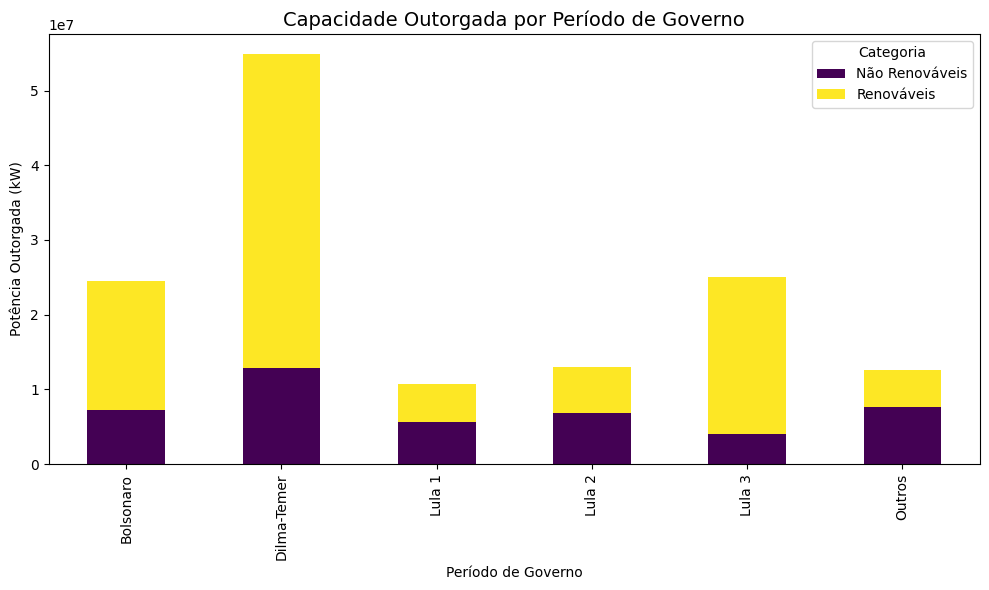

In [10]:
period_pivot = period_group.pivot(index="period", columns="renewable", values="potncia_outorgada_kw").fillna(0)
period_pivot.rename(columns={True: "Renováveis", False: "Não Renováveis"}, inplace=True)

period_pivot.plot(kind="bar", stacked=True, figsize=(10,6), colormap="viridis")
plt.title("Capacidade Outorgada por Período de Governo", fontsize=14)
plt.xlabel("Período de Governo")
plt.ylabel("Potência Outorgada (kW)")
plt.legend(title="Categoria")
plt.tight_layout()
plt.show()


In [11]:
import statsmodels.api as sm

# Agregado por ano (somente renováveis)
renew_year = df[df["renewable"]==True].groupby("year")["potncia_outorgada_kw"].sum().reset_index()

# Regressão linear simples (potência renovável ~ tempo)
X = sm.add_constant(renew_year["year"])
y = renew_year["potncia_outorgada_kw"]

model = sm.OLS(y, X).fit()
print(model.summary())


                             OLS Regression Results                             
Dep. Variable:     potncia_outorgada_kw   R-squared:                       0.341
Model:                              OLS   Adj. R-squared:                  0.314
Method:                   Least Squares   F-statistic:                     12.44
Date:                  Fri, 12 Sep 2025   Prob (F-statistic):            0.00172
Time:                          01:38:20   Log-Likelihood:                -420.34
No. Observations:                    26   AIC:                             844.7
Df Residuals:                        24   BIC:                             847.2
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -4.873e+08   1.39e+08

In [12]:
from statsmodels.tsa.arima.model import ARIMA

# Séries anuais renováveis
series = renew_year.set_index("year")["potncia_outorgada_kw"]

# ARIMA(1,1,1) como exemplo
model = ARIMA(series, order=(1,1,1))
result = model.fit()

print(result.summary())

# Previsão até 2030
forecast = result.get_forecast(steps=5)
pred = forecast.predicted_mean
conf = forecast.conf_int()

print(pred)


                                SARIMAX Results                                 
Dep. Variable:     potncia_outorgada_kw   No. Observations:                   26
Model:                   ARIMA(1, 1, 1)   Log Likelihood                -408.218
Date:                  Fri, 12 Sep 2025   AIC                            822.436
Time:                          01:38:20   BIC                            826.093
Sample:                               0   HQIC                           823.450
                                   - 26                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1796      0.492      0.365      0.715      -0.785       1.144
ma.L1         -0.7828      0.285     -2.751      0.006      -1.340      -0.225
sigma2      1.107e+13   7.31e-14   1

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

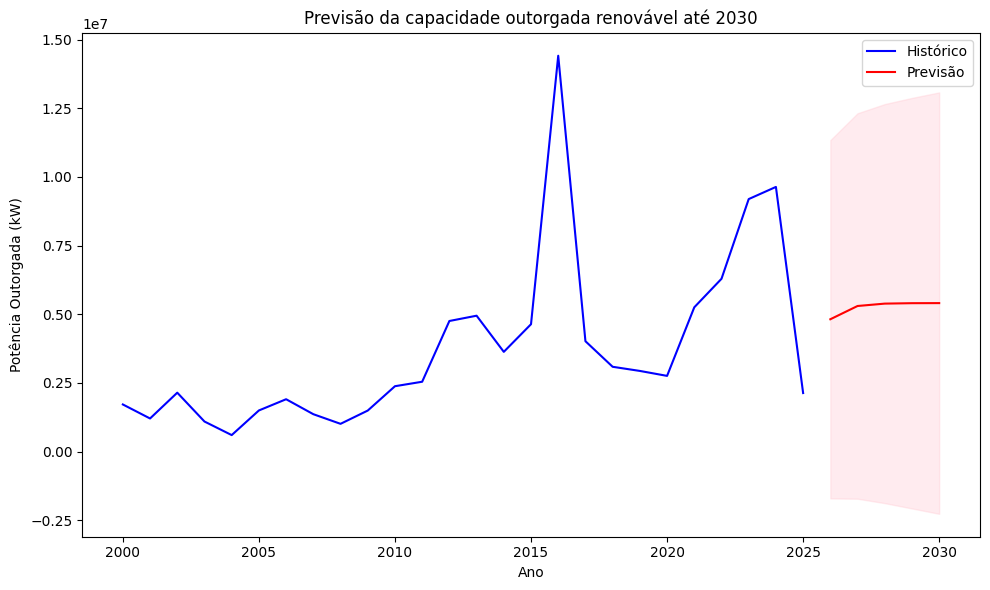

In [13]:
import matplotlib.pyplot as plt

# Ajustar índice
series = renew_year.set_index("year")["potncia_outorgada_kw"]

# ARIMA
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(series, order=(1,1,1))
result = model.fit()

# Previsão até 2030
forecast = result.get_forecast(steps=5)  # 2026-2030
pred = forecast.predicted_mean
conf = forecast.conf_int()

# Plot
plt.figure(figsize=(10,6))
plt.plot(series.index, series, label="Histórico", color="blue")
plt.plot(range(series.index[-1]+1, series.index[-1]+1+len(pred)), pred, label="Previsão", color="red")
plt.fill_between(range(series.index[-1]+1, series.index[-1]+1+len(pred)),
                 conf.iloc[:,0], conf.iloc[:,1], color="pink", alpha=0.3)
plt.title("Previsão da capacidade outorgada renovável até 2030")
plt.xlabel("Ano")
plt.ylabel("Potência Outorgada (kW)")
plt.legend()
plt.tight_layout()
plt.show()
